In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# LOAD DATA FROM PIPELINE
df = pd.read_csv('commodity_data.csv', index_col='Date', parse_dates=True)

# CREATE SPREAD
spread = df['Brent'] - df['WTI']

print(df.tail())
print('\nSpread tail:')
print(spread.tail())

                Brent        WTI         DXY         Gold  Copper  NatGas  \
Date                                                                        
2026-06-04  95.029999  93.040001   99.410004  4475.799805  6.5110   3.336   
2026-06-05  93.089996  90.540001  100.070000  4337.100098  6.2635   3.229   
2026-06-08  94.250000  91.300003  100.050003  4335.899902  6.3295   3.147   
2026-06-09  91.449997  88.199997   99.910004  4260.000000  6.3025   3.140   
2026-06-10  94.379997  91.529999   99.918999  4115.899902  6.2395   3.193   

                  SP500  
Date                     
2026-06-04  7584.310059  
2026-06-05  7383.740234  
2026-06-08  7405.729980  
2026-06-09  7386.649902  
2026-06-10  7266.990234  

Spread tail:
Date
2026-06-04    1.989998
2026-06-05    2.549995
2026-06-08    2.949997
2026-06-09    3.250000
2026-06-10    2.849998
dtype: float64


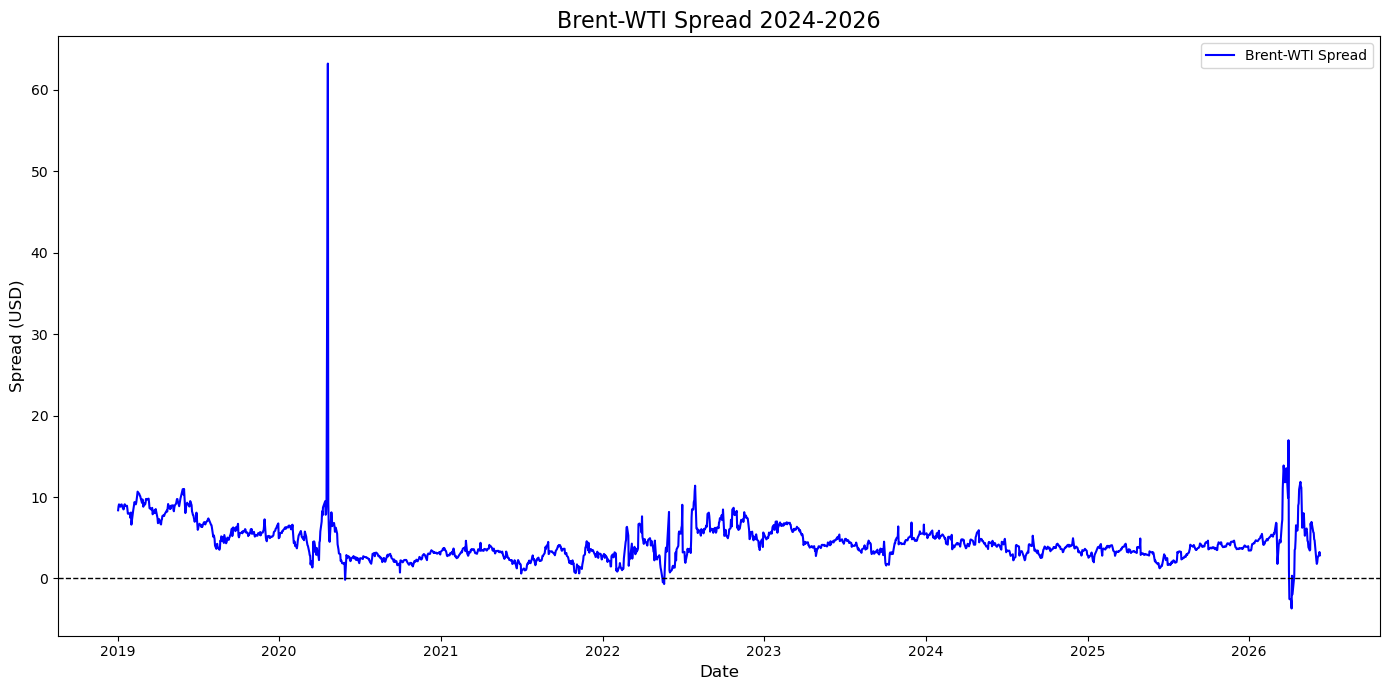

In [7]:
# PLOT THE SPREAD
plt.figure(figsize=(14,7))
plt.plot(spread, label='Brent-WTI Spread', color='blue', linewidth=1.5)
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Brent-WTI Spread 2024-2026', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Spread (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

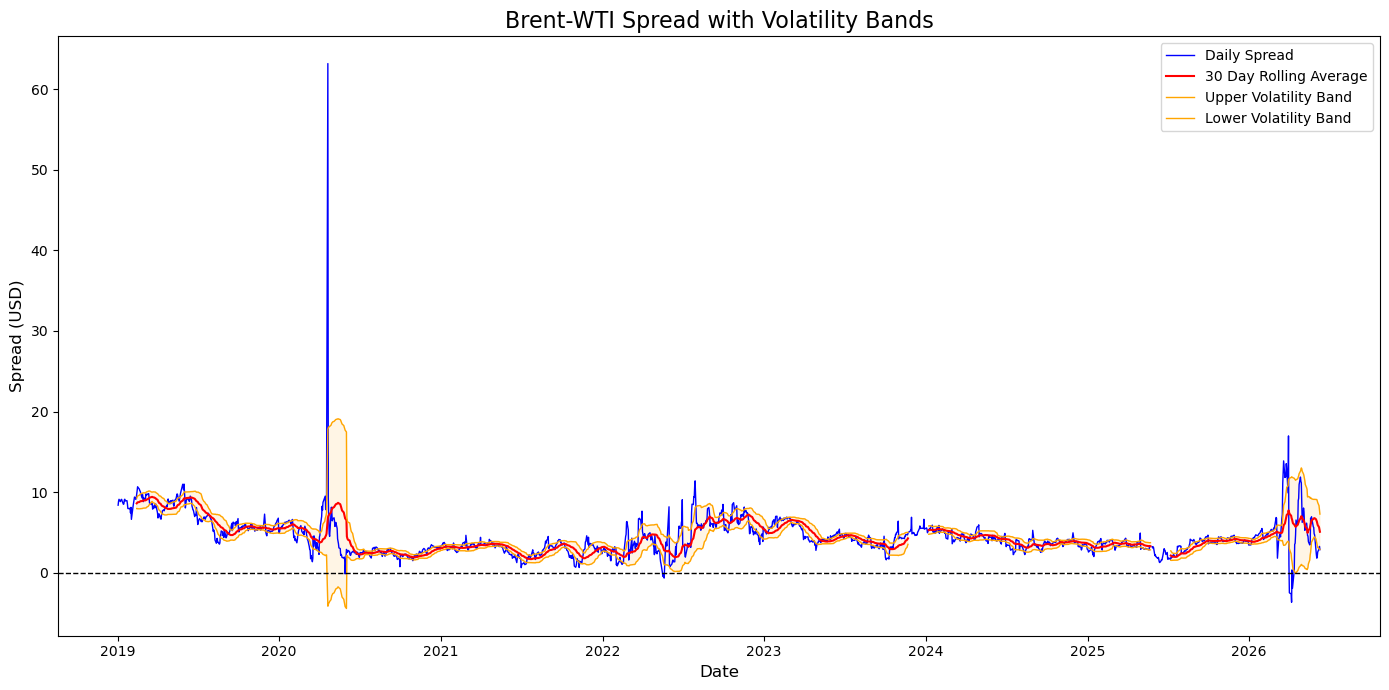

In [8]:
# CALCULATE ROLLING METRICS
spread_30day_avg = spread.rolling(window=30).mean()
spread_std30 = spread.rolling(window=30).std()
upper_band = spread_30day_avg + spread_std30
lower_band = spread_30day_avg - spread_std30

# PLOT
plt.figure(figsize=(14,7))
plt.plot(spread, label='Daily Spread', color='blue', linewidth=1)
plt.plot(spread_30day_avg, label='30 Day Rolling Average', color='red', linewidth=1.5)
plt.plot(upper_band, label='Upper Volatility Band', color='orange', linewidth=1)
plt.plot(lower_band, label='Lower Volatility Band', color='orange', linewidth=1)
plt.fill_between(spread.index, upper_band, lower_band, alpha=0.1, color='orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Brent-WTI Spread with Volatility Bands', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Spread (USD)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

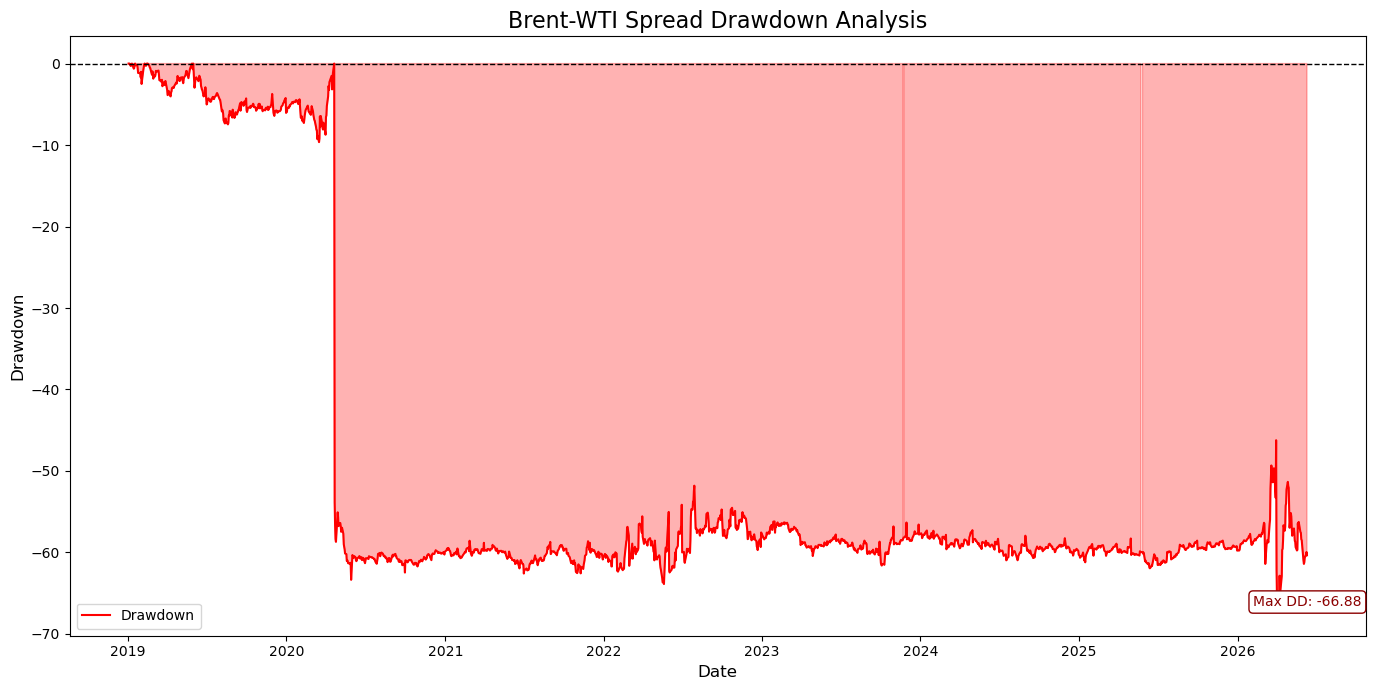

In [9]:
# CALCULATE DRAWDOWN
rolling_max = spread.cummax()
drawdowns = spread - rolling_max

# PLOT
plt.figure(figsize=(14,7))
plt.plot(drawdowns, label='Drawdown', color='red', linewidth=1.5)
plt.fill_between(drawdowns.index, drawdowns, 0, alpha=0.3, color='red')
plt.axhline(0, color='black', linestyle='--', linewidth=1)

# ANNOTATE MAX DRAWDOWN
min_idx = drawdowns.idxmin()
plt.annotate(f'Max DD: {drawdowns.min():.2f}',
             xy=(min_idx, drawdowns.min()),
             xytext=(min_idx - pd.Timedelta(days=60), drawdowns.min() + 0.3),
             arrowprops=dict(arrowstyle='->'),
             color='darkred', fontsize=10,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='darkred'))

plt.title('Brent-WTI Spread Drawdown Analysis', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Drawdown', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

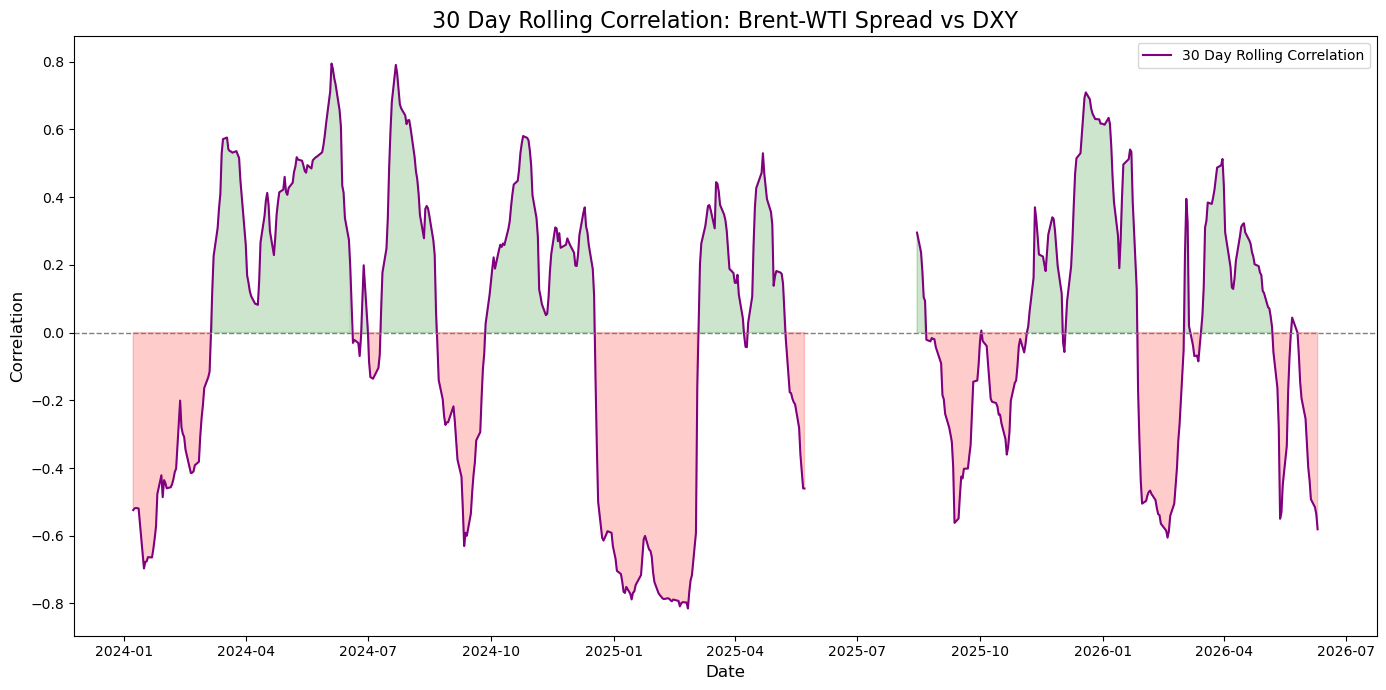

In [10]:
# CALCULATE 30 DAY ROLLING CORRELATION
rolling_corr = spread.rolling(30).corr(df['DXY'])

# FILTER TO 2024 ONWARDS
rolling_corr_2024 = rolling_corr['2024-01-01':]

# PLOT
plt.figure(figsize=(14,7))
plt.plot(rolling_corr_2024, label='30 Day Rolling Correlation', color='purple', linewidth=1.5)
plt.fill_between(rolling_corr_2024.index, rolling_corr_2024, 0,
                 where=(rolling_corr_2024 > 0), color='green', alpha=0.2)
plt.fill_between(rolling_corr_2024.index, rolling_corr_2024, 0,
                 where=(rolling_corr_2024 < 0), color='red', alpha=0.2)
plt.axhline(0, color='grey', linestyle='--', linewidth=1)
plt.title('30 Day Rolling Correlation: Brent-WTI Spread vs DXY', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Correlation', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

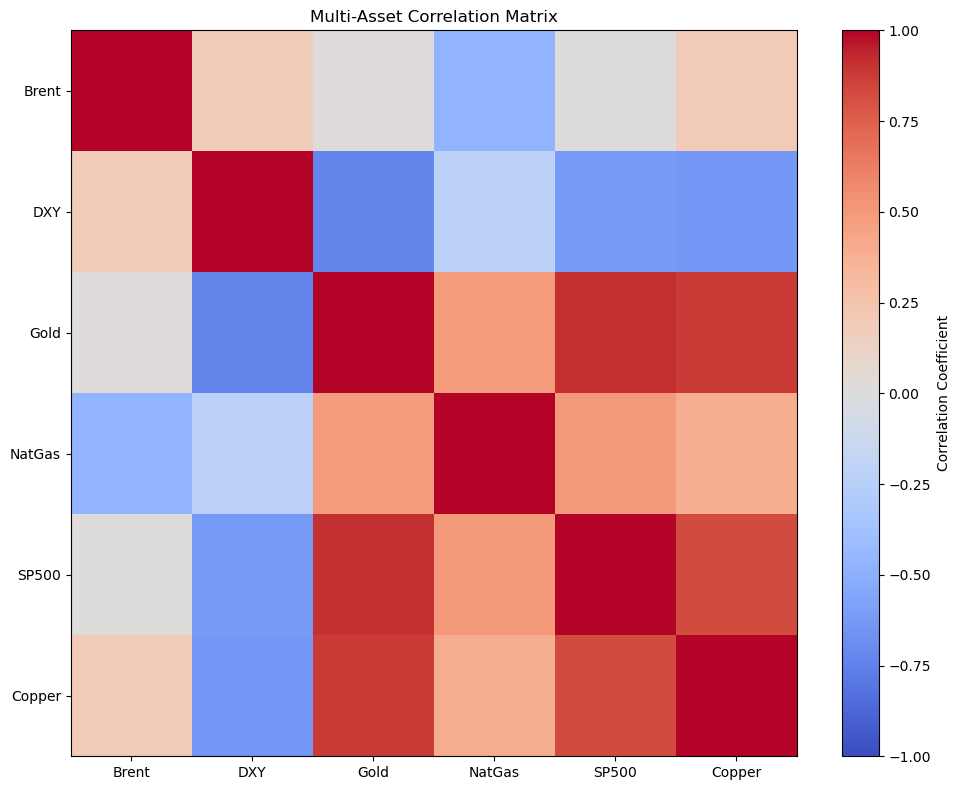

In [11]:
# SELECT ASSETS FOR MATRIX
matrix_data = df[['Brent', 'DXY', 'Gold', 'NatGas', 'SP500', 'Copper']]['2024-01-01':]

# CALCULATE CORRELATION
correlation_matrix = matrix_data.corr()

# PLOT
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlation Coefficient')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title('Multi-Asset Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()